<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/lab5/Lab5_AI_11971.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import pandas as pd

from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam

import math

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

from keras.losses import Huber
from keras.losses import LogCosh

In [84]:
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()


def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("-" * 30)
    print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
    print("-" * 30)


def return_mae(test, predicted):
    mae = mean_absolute_error(test, predicted)
    mape = mean_absolute_percentage_error(test, predicted) * 100
    print("Średni błąd bezwzględny: {:.2f}".format(mae))
    print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
    print("-" * 30)

In [85]:
dataset = pd.read_csv(
    'IBM_2006-01-01_to_2018-01-01.csv',
    index_col='Date',
    parse_dates=['Date']
)

dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [86]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

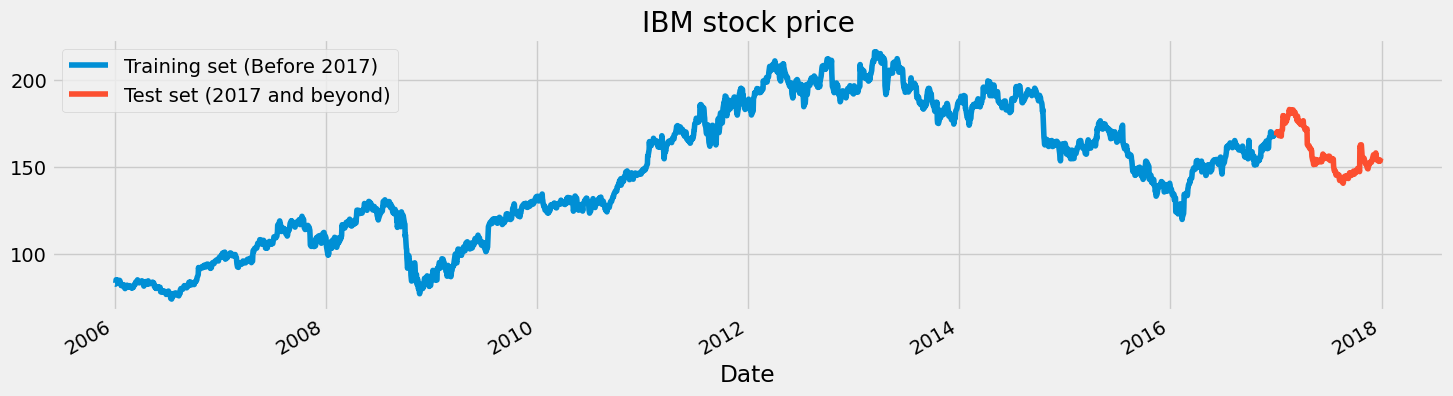

In [87]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)

plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [88]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [89]:
X_train = []
y_train = []

for i in range(60, 2769):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [90]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

In [91]:
regressor = Sequential()

# Warstwa wejściowa
regressor.add(Input(shape=(X_train.shape[1], 1)))

# 1 warstwa LSTM
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# 2 warstwa LSTM
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# 3 warstwa LSTM
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# 4 warstwa LSTM
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Wyjście
regressor.add(Dense(units=1))

# Kompilacja modelu
regressor.compile(
    optimizer='adam',
    loss='huber'
)

# Trenowanie
regressor.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0112
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0023
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0019
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0017
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0016
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0016
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0014
Epoc

In [92]:
dataset_total = pd.concat(
    (dataset["High"][:'2016'], dataset["High"]['2017':]),
    axis=0
)

inputs = dataset_total[
    len(dataset_total) - len(test_set) - 60:
].values

inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [93]:
X_test = []

for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


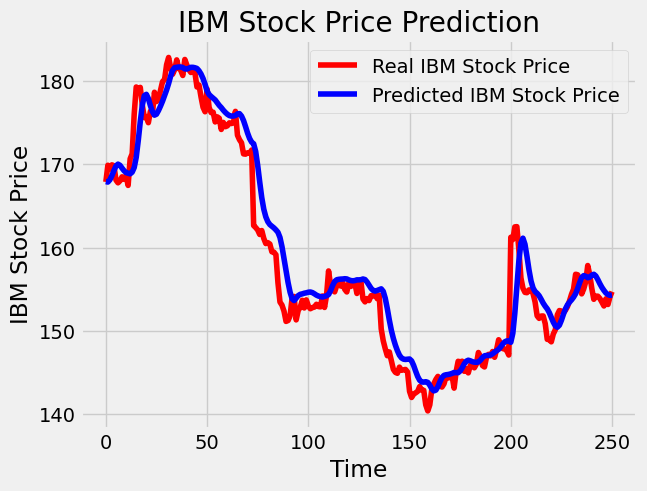

In [94]:
plot_predictions(test_set, predicted_stock_price)

In [95]:
return_rmse(test_set, predicted_stock_price)
return_mae(test_set, predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 2.88.
------------------------------
Średni błąd bezwzględny: 2.03
Średni błąd bezwzględny procentowy: 1.28%
------------------------------


In [98]:
regressorGRU = Sequential()

# Warstwa wejściowa
regressorGRU.add(Input(shape=(X_train.shape[1], 1)))

# 1 warstwa GRU
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# 2 warstwa GRU
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# 3 warstwa GRU
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# 4 warstwa GRU
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Wyjście
regressorGRU.add(Dense(units=1))

# Kompilacja
regressorGRU.compile(
    optimizer='adam',
    loss= LogCosh()
)

# Trenowanie
regressorGRU.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0109
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0020
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0018
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0016
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0014
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0014
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0013
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0011
Epoc

In [99]:
X_test = []

for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

GRU_predicted_stock_price = regressorGRU.predict(X_test)

GRU_predicted_stock_price = sc.inverse_transform(
    GRU_predicted_stock_price
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


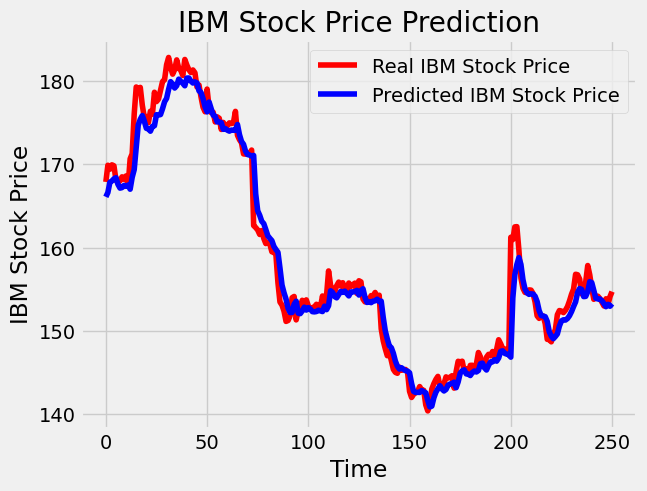

In [100]:
plot_predictions(test_set, GRU_predicted_stock_price)

In [101]:
return_rmse(test_set, GRU_predicted_stock_price)

return_mae(test_set, GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 2.04.
------------------------------
Średni błąd bezwzględny: 1.37
Średni błąd bezwzględny procentowy: 0.85%
------------------------------
